# **Classification Course**

---

In this course, you will learn how to apply ***the supervised learning workflow (explained in Section 4 of the lecture) to classification problems***. We will use **"decision tree" model** throughout the exercises and look at each step of the workflow: ***understanding the data, processing data, model building, and model evaluation***.The goal is to practice the knowledge required for each step depending on the level.

# Level 2 (★★☆)
---
In Level 2, we’ll build a predictive model using data where the missing values have been assign with some data. What kinds of values work best when you fill in missing data?

## 2.1. Understanding the Data (Part 1)

In Level 2, we’ll continue using the "poisonous mushroom appearance data" from Level 1. As a review of Level 1, please download the CSV file from the link below and upload it to the specified location. Then, let's try to read the data into a DataFrame with the following code.

[Mushroom_Appearence_Data.csv](https://drive.google.com/file/d/19NKE8PgEhgE9b5WZnFgmWkZ-D2DR2NIe/view?usp=drive_link)

In [ ]:
# Import pandas
import pandas as pd

# Load CSV file
df = pd.read_csv('Mushroom_Appearence_Data.csv')

This time, let’s explore summary statistics—single values like the mean, median, or mode—that capture how our data are distributed. For numerical or ordinal data, the mean and median are commonly used. However, since we’re working with qualitative data here, we’ll use the **mode** to assign missing values. The mode is the value that occurs most frequently in the dataset.

To check the summary statistics of a specific column in a DataFrame, first extract the column as a Series object, then apply the `describe()` method. For example, we can extract the `bruises` column, which contains missing values, and display its summary statistics using the `describe()` method.

In [ ]:
df['bruises'].describe()

,bruises
count,6500
unique,2
top,N
freq,3776


In the output, the index labels have the following meanings: **count** is the number of non-missing values, **unique** is the number of unique categories, **top** is the mode (most frequent value), and **freq** is the frequency of the mode.

Since the `bruises` are qualitative data, we were able to obtain statistics such as the mode.
However, for quantitative data, we can also get representative values like the mean and median, as well as statistics such as the standard deviation.

You can access the corresponding value by specifying the index in square brackets on the Series returned by the `describe()` method. To get the mode, specify `['top']`. From the result, we can see that the most common value in the `bruises` column is 'N', indicating no bruises.

In [ ]:
top = df['bruises'].describe()['top']
top

'N'

## 2.2. Preprocessing Data (Part 1)

In Level 2, instead of dropping missing data as we did before, we’ll fill them using representative values like the mode. You can either replace each missing entry with that column’s most frequent value or infer it by looking at related columns.

**[Handling Missing Values]**

*   **Deleting Missing Values (Level 1★☆☆)**
    *   Deleting columns with missing values
    *   Deleting rows with missing values
*   **Replacing Missing Values (Level 2★★☆)**
    *   Replacing with the mean of the column with missing values
    *   Replacing with values from other columns except the one with missing values

First, let’s try filling in the missing values using the mode of each column.
To fill missing values, we use the `fillna()` method of a DataFrame and pass the mode as the argument.
We can use the `isnull()` and `sum()` methods to confirm that all missing values have been filled.
Since the `fillna()` method returns a new DataFrame with missing values filled, we assign it to a new variable called `df_fill`.

In [ ]:
# Fill missing values with the mode
df_fill = df.fillna(top)
# Check the number of missing values
df_fill.isnull().sum()

,0
ID,0
bruises,0
cap_color,0
poison,0


Note that the `fillna()` method does not modify the original DataFrame. Instead, it returns a new one. Let’s check that any missing values still remain in the original `df`.

In [ ]:
# Check the number of missing values in the original df
df.isnull().sum()

,0
ID,0
bruises,1624
cap_color,0
poison,0


Next, we will againt create dummy variables and split the data into training and test sets.

In [ ]:
df_dummy = pd.get_dummies(df_fill[['cap_color', 'bruises']], drop_first= True)

x = df_dummy
y = df_fill['poison']

from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y)

>**[When to split train and test data]**
>
>In this example, we assigned missing values using the mode before splitting the data into train and test sets.
However, this approach is not recommended.
Replacing missing values before the train-test split can cause data leakage, where information from the test set accidentally influences the training process.
In this particular case, the result may not change because the mode stays the same if there is no bias in the data.
But in the real world, we should always avoid information leakage from the test set.

## 2.3. Model Building and Evaluation (Part 1)

Now that the data is ready, let’s build and evaluate the model, just like we did before.

In [ ]:
from sklearn.tree import  DecisionTreeClassifier
model = DecisionTreeClassifier()
model.fit(x_train, y_train)

test_score = model.score(x_test, y_test)
round(test_score, 3)

0.768

When missing values were replaced using the mode, the accuracy slightly decreased compared to when rows with missing values were simply removed. However, the accuracy was higher than when entire columns with missing values were removed. By replacing missing values, we can now make predictions even when future data contains missing values. Next, we’ll look at a method that fills in missing values using information from other features without missing data.

## 2.4. Understanding the Data (Part 2)

Previously, we filled in missing values using the mode of all the data.
However, some features in the data may be related to each other.
For example, white mushrooms may be more likely to have spots.
Last time, we ignored such relationships and used the overall mode to fill in missing values.
This time, let’s group the data by `cap_color` and examine the mode of the `spots` column within each group.

When using the `groupby()` method of a DataFrame object in Pandas, you can group rows that have the same value in a specific column and perform calculations on each group.
You specify the column inside the parentheses of the groupby method, and then select the column to calculate after that.
Additionally, the `describe()` method returns a DataFrame where each group is an index and the statistical summaries are the columns.
If you select the `top` row from the result, you can extract the mode for each group.
The diagram below shows how the process works.

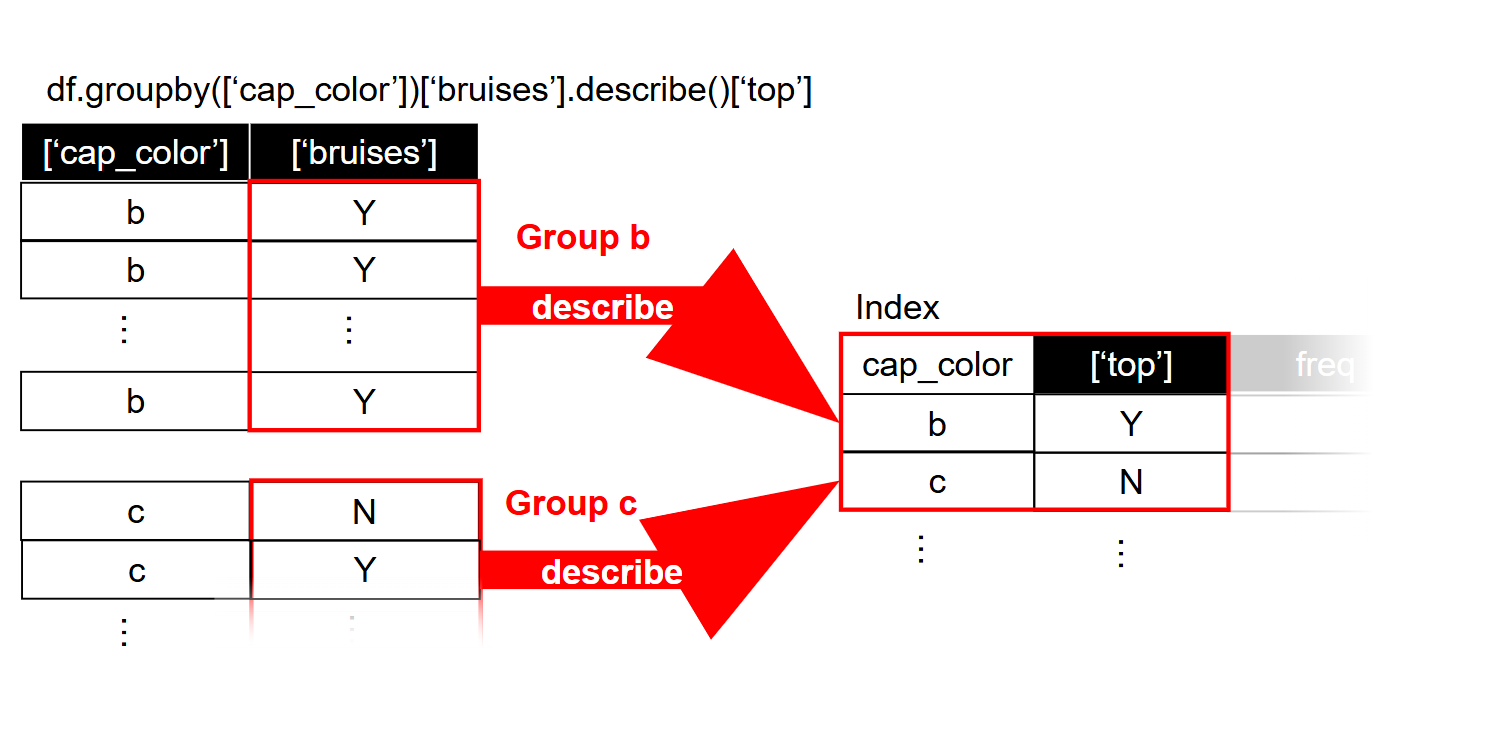

In [ ]:
tops = df.groupby(['cap_color'])['bruises'].describe()['top']
tops

,top
cap_color,
b,Y
c,N
e,N
g,N
n,N
p,Y
r,N
u,N
w,Y


The aggregation results show that the mode of the `bruises` column varies depending on the mushroom’s cap color.

## 2.5. Preprocessing Data (Part 2)

This time, we’ll fill in missing values based on the mushroom’s cap color.
The `loc[]` attribute is used to access or assign specific rows or row-column pairs in a DataFrame.
First, let’s extract only the rows that contain missing values.
To do this, pass a Boolean Series indicating missing values inside the square brackets of `loc[]` attribute. You can create this Boolean Series using the `isnull()` method, which was introduced in Level 1.
The key difference here is that we’re applying `isnull()` method to the `bruises` column only, because we don’t need information about missing values in the other columns.

In [ ]:
is_null = df['bruises'].isnull()
is_null.head()

,bruises
0,False
1,False
2,False
3,True
4,True


In [ ]:
df.loc[is_null].head()

,ID,bruises,cap_color,poison
3,4,NaN,w,Y
4,5,NaN,g,N
5,6,NaN,y,N
14,15,NaN,n,N
20,21,NaN,y,N


We were able to extract only the rows with missing values (evaluated as `True`) by using the `loc[]` attribute with the Boolean Series returned by the `isnull()` method.
Next, let’s group the data by cap color. First, let's check the colors of the first 5 rows.

In [ ]:
df['cap_color'].head()

,cap_color
0,n
1,y
2,w
3,w
4,g


You can see that the values at index 2 and 3 are `w` (white).

First, we’ll create a Boolean Series to check whether each row has the same color as the missing value. Then, we’ll use the `loc[]` attribute to extract those rows.
To compare values, use the double equal sign (`==`) comparison operator.
In this case, we compare the values in the cap_color column with `'w'` (white) using `==`.
This comparison returns a Boolean Series, which we assign to the variable `is_white`.

In [ ]:
is_white = df['cap_color'] == 'w'
is_white.head()

,cap_color
0,False
1,False
2,True
3,True
4,False


Only the rows where the cap color is white will be evaluated as `True`; the rest will be `False`.
By passing this Boolean Series to the `loc[]` attribute, you can extract the rows where the condition is `True`, just like when we handled missing values earlier.

In [ ]:
df.loc[is_white].head()

,ID,bruises,cap_color,poison
2,3,Y,w,N
3,4,NaN,w,Y
6,7,Y,w,N
7,8,Y,w,N
8,9,Y,w,Y


Now, let’s combine the conditions for cap color and missing values to extract the relevant rows.
To apply both conditions at once, use the `&` operator.

In [ ]:
df.loc[is_null & is_white].head()

,ID,bruises,cap_color,poison
3,4,NaN,w,Y
31,32,NaN,w,Y
95,96,NaN,w,N
107,108,NaN,w,N
108,109,NaN,w,N


If you want to extract rows where at least one of the conditions is met, use the `|` operator.
For example, if you have two Boolean Series, A and B, the results will look like this:

| SeriesA | SeriesB | SeriesA & SeriesB | SeriesA \| SeriesB |
|---------|---------|-------------------|---------------------|
| True    | True    | True              | True                |
| True    | False   | False             | True                |
| False   | True    | False             | True                |
| False   | False   | False             | False               |

Now that we’ve extracted the rows where cap color is white and bruises is missing,
we can also extract only the specific column by adding a comma and column name inside the loc brackets.

In [ ]:
df.loc[is_white & is_null,'bruises'].head()

,bruises
3,NaN
31,NaN
95,NaN
107,NaN
108,NaN


We were able to extract only the rows with missing values. Finally, we will fill them using the most frequent value for each cap color.
The values to be assigned are stored in the `tops` variable, where each cap color maps to its mode.
In the following code, we combine the color condition and missing value condition directly in the loc statement.
Make sure to wrap the combined condition in parentheses.

In [ ]:
df.loc[(df['cap_color'] == 'b') & (is_null),'bruises'] = tops['b']
df.loc[(df['cap_color'] == 'c') & (is_null),'bruises'] = tops['c']
df.loc[(df['cap_color'] == 'e') & (is_null),'bruises'] = tops['e']
df.loc[(df['cap_color'] == 'g') & (is_null),'bruises'] = tops['g']
df.loc[(df['cap_color'] == 'n') & (is_null),'bruises'] = tops['n']
df.loc[(df['cap_color'] == 'p') & (is_null),'bruises'] = tops['p']
df.loc[(df['cap_color'] == 'r') & (is_null),'bruises'] = tops['r']
df.loc[(df['cap_color'] == 'u') & (is_null),'bruises'] = tops['u']
df.loc[(df['cap_color'] == 'w') & (is_null),'bruises'] = tops['w']
df.loc[(df['cap_color'] == 'y') & (is_null),'bruises'] = tops['y']

Next, as usual, let's split the data into training and test sets, and train the model.

In [ ]:
df_dummy = pd.get_dummies(df[['cap_color', 'bruises']], drop_first= True)

x = df_dummy
y = df['poison']

x_train, x_test, y_train, y_test = train_test_split(x, y)

## 2.6. Model Building and Evaluation (Part 2)

The training process is the same as before.

In [ ]:
model = DecisionTreeClassifier()
model.fit(x_train, y_train)

test_score = model.score(x_test, y_test)
round(test_score, 3)

0.747

In this case, the choice of imputation method did not change the results, but that can vary depending on the dataset. Additionally, although we did not cover it here, there is also an approach in which the presence of missing values themselves is treated as a label to be predicted.
In that case, decision trees are used twice: once to predict missing values and again to predict the target variable.
That wraps up the section on handling missing values.
In the next level, we’ll explore how to merge data.

## 2.7. Practice Problems

**Q2-1**. Download the file `Classification_Practice.csv` from the link below, upload the file, and read it as a pandas DataFrame. Then, display the first 5 rows to check the data.

[Classification_Practice.csv](https://drive.google.com/file/d/1jiozgbJXrdWIpVvQSOSlAB8a59gYjI_x/view?usp=drive_link)

**Q2-2**. Check how many missing values there are in each column.

**Q2-3**. Check the mode of the column named `columns1`.

**Q2-4**. Fill the missing values in `columns1` using the mode from Q2-3, and assign the resulting DataFrame to the variable `df_fill`.

**Q2-5**. Group the data by the values in `columns2`, and check the mode of `columns1` within each group.

**Q2-6**. Using the groups from Q2-5, fill in the missing values in `columns1` with the mode calculated within each group based on `columns2`.